# Rain Gauge Data Processing
This notebook processes raw precipitation data from three rain gauges (Gazelle Valley, Ziv, and Givat Ram), preparing them for further analysis.

Key steps:
- Load and parse raw CSV data, standardizing timestamps.

- Resample to fixed time intervals (5 or 10 minutes for LAB gauges, auto-detected for IMS).

- Compute rain intensity (mm/hr).

- For LAB gauges, set all rainfall values in July and August to zero (to remove false dew/heat-related readings).

- Export cleaned data to CSV files with a _processed suffix.



# Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime
from collections import Counter
import os


# Functions

In [2]:
def process_lab_gauge_precipitation_data(file_path, interval_minutes=10):
    """
    Processes LAB gauge precipitation data, removes summer false rainfall (e.g., dew in July–August).

    Parameters:
    - file_path (str): Path to the CSV file containing the data.
    - interval_minutes (int): Resampling interval in minutes (default is 10). Only 5 or 10 are allowed.

    Returns:
    - pd.DataFrame: DataFrame with datetime, rain, cumulative rain, and intensity.
    """

    if interval_minutes not in [5, 10]:
        raise ValueError("Interval must be either 5 or 10 minutes.")

    # Load and set datetime index
    df = pd.read_csv(file_path, parse_dates=['Date Time'], dayfirst=True)
    df.set_index('Date Time', inplace=True)

    # Set default rain value
    df['rain_mm'] = 0.1

    # Resample
    interval = pd.Timedelta(minutes=interval_minutes)
    df_resampled = df.resample(interval).sum()

    # Reset index column
    df_resampled['date_time'] = pd.to_datetime(df_resampled.index.round(interval))

    # ✅ Set rain to 0 during July and August
    df_resampled.loc[df_resampled['date_time'].dt.month.isin([7, 8]), 'rain_mm'] = 0.0

    # Calculate cumulative and intensity
#     df_resampled['cumulative_rain_mm'] = df_resampled['rain_mm'].cumsum()
    df_resampled['rain_intens_10min_mm_hr'] = df_resampled['rain_mm'] * (60 / interval_minutes)

    # Reorder and clean
    df_resampled = df_resampled[['date_time',  'rain_mm', 'rain_intens_10min_mm_hr']]
    df_resampled.reset_index(drop=True, inplace=True)

    return df_resampled



def process_ims_gauge_precipitation_data(file_path):
    """
    Processes IMS gauge precipitation data. Infers time step, fills gaps with 0.
    Parameters:
    - file_path (str): Path to CSV file.
    Returns:
    - pd.DataFrame with: 'date_time', 'cumulative_rain_mm', 'rain_mm', 'rain_intens_10min_mm_hr'.
    """
    df = pd.read_csv(file_path, parse_dates=['Date Time'], dayfirst=True)
    df['Date Time'] = pd.to_datetime(df['Date Time'], format='%d/%m/%Y %H:%M', errors='coerce')
    df.dropna(subset=['Date Time', 'Rain (mm)'], inplace=True)
    df.sort_values('Date Time', inplace=True)
    df.set_index('Date Time', inplace=True)
    df.rename(columns={'Rain (mm)': 'rain_mm'}, inplace=True)

    diffs = df.index.to_series().diff().dropna().dt.total_seconds()
    counter = Counter(diffs.round())
    most_common_step = int(counter.most_common(1)[0][0])
    freq_str = f'{most_common_step // 60}T'
    print("⏱️ Givat Ram Time step breakdown:", counter)
    print(f"✅ Using resample interval: {freq_str}")

    df_resampled = df.resample(freq_str).sum().fillna(0.0)
    df_resampled.reset_index(inplace=True)
    df_resampled.rename(columns={'Date Time': 'date_time'}, inplace=True)
#     df_resampled['cumulative_rain_mm'] = df_resampled['rain_mm'].cumsum()
    df_resampled['rain_intens_10min_mm_hr'] = df_resampled['rain_mm'] * (3600 / most_common_step)

    return df_resampled[['date_time', 'rain_mm', 'rain_intens_10min_mm_hr']]


def plot_rain_intensity(rain_dfs, start_date, end_date):
    start_date = datetime.strptime(start_date, '%d/%m/%Y %H:%M')
    end_date = datetime.strptime(end_date, '%d/%m/%Y %H:%M')
    filtered_dfs = [df[(df['date_time'] >= start_date) & (df['date_time'] <= end_date)] for df in rain_dfs]

    plt.figure(figsize=(12, 6))
    for i, df in enumerate(filtered_dfs):
        plt.plot(df['date_time'], df['rain_intens_10min_mm_hr'], label=f'{rain_dfs[i].name}')

    plt.title('Rain Intensity (mm/hr)')
    plt.xlabel('Date Time')
    plt.ylabel('Rain Intensity (mm/hr)')
    plt.legend()
    plt.grid(True)

    num_ticks = 10
    plt.tick_params(axis='x', which='major', labelsize=12)
    plt.xticks(filtered_dfs[0]['date_time'].iloc[::len(filtered_dfs[0]) // num_ticks], rotation=45)
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d/%m/%Y %H'))
    plt.ylim(0)
    plt.xlim(filtered_dfs[0]['date_time'].iloc[0], end_date)
    plt.tight_layout()
    plt.show()


def plot_cumulative_rain(rain_dfs, start_date, end_date):
    """
    Plots cumulative rain (mm) for multiple DataFrames within a specified date range.
    Cumulative rain is calculated inside this function.

    Parameters:
    - rain_dfs (list): List of DataFrames with 'date_time' and 'rain_mm' columns.
    - start_date (str): Start date (format: '%d/%m/%Y %H:%M').
    - end_date (str): End date (format: '%d/%m/%Y %H:%M').
    """
    start_date = datetime.strptime(start_date, '%d/%m/%Y %H:%M')
    end_date = datetime.strptime(end_date, '%d/%m/%Y %H:%M')

    filtered_dfs = []
    for df in rain_dfs:
        filtered = df[(df['date_time'] >= start_date) & (df['date_time'] <= end_date)].copy()
        filtered['cumulative_rain_mm'] = filtered['rain_mm'].cumsum()
        filtered_dfs.append(filtered)

    plt.figure(figsize=(12, 6))
    for i, df in enumerate(filtered_dfs):
        plt.plot(df['date_time'], df['cumulative_rain_mm'], label=f'{rain_dfs[i].name}')

    plt.title('Cumulative Rain (mm)')
    plt.xlabel('Date Time')
    plt.ylabel('Cumulative Rain (mm)')
    plt.legend()
    plt.grid(True)

    num_ticks = 10
    plt.tick_params(axis='x', which='major', labelsize=12)
    plt.xticks(filtered_dfs[0]['date_time'].iloc[::len(filtered_dfs[0]) // num_ticks], rotation=45)
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d/%m/%Y %H'))
    plt.ylim(0)
    plt.xlim(filtered_dfs[0]['date_time'].iloc[0], end_date)
    plt.tight_layout()
    plt.show()


def save_processed_rain(df, original_path):
    """
    Saves processed rain DataFrame next to original file with '_processed' suffix.
    """
    directory, original_filename = os.path.split(original_path)
    name, ext = os.path.splitext(original_filename)
    output_filename = f"{name}_processed.csv"
    output_path = os.path.join(directory, output_filename)
    df.to_csv(output_path, index=False)
    print(f"✅ Saved processed file to:\n{output_path}")

    

In [3]:
def process_ims_gauge_precipitation_data(file_path):
    from collections import Counter

    df = pd.read_csv(file_path, parse_dates=['Date Time'], dayfirst=True)
    df['Date Time'] = pd.to_datetime(df['Date Time'], format='%d/%m/%Y %H:%M', errors='coerce')
    df = df.dropna(subset=['Date Time', 'Rain (mm)'])
    df = df[~df['Date Time'].duplicated(keep='first')]
    df['Date Time'] = df['Date Time'].dt.tz_localize(None)
    df.set_index('Date Time', inplace=True)
    df.rename(columns={'Rain (mm)': 'rain_mm'}, inplace=True)

    # Infer time step
    diffs = df.index.to_series().diff().dropna().dt.total_seconds()
    counter = Counter(diffs.round())
    most_common_step = int(counter.most_common(1)[0][0])
    freq_str = f'{most_common_step // 60}T'
    print("⏱️ Givat Ram Time step breakdown:", counter)
    print(f"✅ Using resample interval: {freq_str}")

    # Resample
    df_resampled = df.resample(freq_str).sum().fillna(0.0)
    df_resampled.index = df_resampled.index.tz_localize(None)
    df_resampled.index.name = 'date_time'

    # Calculate intensity
    df_resampled['rain_intens_10min_mm_hr'] = df_resampled['rain_mm'] * (3600 / most_common_step)

    # Final clean
    df_resampled = df_resampled.reset_index()
    df_resampled = df_resampled[['date_time', 'rain_mm', 'rain_intens_10min_mm_hr']]
    df_resampled = df_resampled.dropna(subset=['date_time'])
    df_resampled = df_resampled[~df_resampled['date_time'].duplicated(keep='first')]
    df_resampled = df_resampled.sort_values('date_time')

    return df_resampled


# Main

In [4]:
# Example usage:
gv_file_path = r"D:\Development\RESEARCH\Gazelle_Valley\Data\Precipiteion_Data\gazelle_valley\20230921_20241117.csv"
ziv_file_path = r'D:\Development\RESEARCH\Gazelle_Valley\Data\Precipiteion_Data\ziv\20230921_20241117.csv'
ram_file_path = r'D:\Development\RESEARCH\Gazelle_Valley\Data\Precipiteion_Data\givat_ram\20230901_20250410.csv'

gv_rain_df = process_lab_gauge_precipitation_data(gv_file_path)
ziv_rain_df = process_lab_gauge_precipitation_data(ziv_file_path)
ram_rain_df = process_ims_gauge_precipitation_data(ram_file_path)

gv_rain_df.name = 'gazelle_valley'
ziv_rain_df.name = 'ziv'
ram_rain_df.name = 'ram'

# Save processed rain data to CSV files
save_processed_rain(gv_rain_df, gv_file_path)
save_processed_rain(ziv_rain_df, ziv_file_path)
save_processed_rain(ram_rain_df, ram_file_path)

⏱️ Givat Ram Time step breakdown: Counter({600.0: 84574, 1200.0: 6, 1800.0: 4, 2400.0: 1})
✅ Using resample interval: 10T
✅ Saved processed file to:
D:\Development\RESEARCH\Gazelle_Valley\Data\Precipiteion_Data\gazelle_valley\20230921_20241117_processed.csv
✅ Saved processed file to:
D:\Development\RESEARCH\Gazelle_Valley\Data\Precipiteion_Data\ziv\20230921_20241117_processed.csv
✅ Saved processed file to:
D:\Development\RESEARCH\Gazelle_Valley\Data\Precipiteion_Data\givat_ram\20230901_20250410_processed.csv


In [14]:
ram_rain_df

,date_time,rain_mm,rain_intens_10min_mm_hr
0,2023-09-01 00:00:00,0.0,0.0
1,2023-09-01 00:10:00,0.0,0.0
2,2023-09-01 00:20:00,0.0,0.0
3,2023-09-01 00:30:00,0.0,0.0
4,2023-09-01 00:40:00,0.0,0.0
...,...,...,...
84598,2025-04-10 11:40:00,0.0,0.0
84599,2025-04-10 11:50:00,0.0,0.0
84600,2025-04-10 12:00:00,0.0,0.0
84601,2025-04-10 12:10:00,0.0,0.0


# Plot

### Is it dew in the summer?

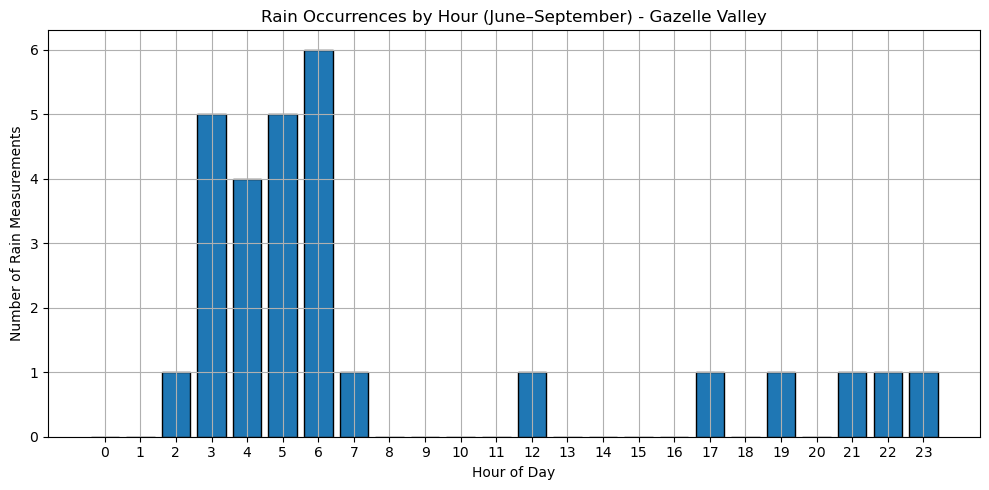

In [5]:
def plot_summer_hourly_rain_histogram(rain_df, station_name='Station'):
    """
    Plots histogram of rain measurements by hour of day during summer months (June–September).

    Parameters:
    - rain_df (pd.DataFrame): Rain data with 'date_time' and 'rain_mm' columns.
    - station_name (str): Name for labeling the station in the plot.
    """
    # Filter for summer months (June=6 to September=9)
    summer_df = rain_df[rain_df['date_time'].dt.month.isin([6, 7, 8, 9])]

    # Keep only rows with positive rain
    summer_df = summer_df[summer_df['rain_mm'] > 0]

    # Extract hour from timestamp
    summer_df['hour'] = summer_df['date_time'].dt.hour

    # Plot histogram
    plt.figure(figsize=(10, 5))
    plt.hist(summer_df['hour'], bins=range(25), edgecolor='black', align='left', rwidth=0.8)
    plt.xticks(range(24))
    plt.xlabel('Hour of Day')
    plt.ylabel('Number of Rain Measurements')
    plt.title(f'Rain Occurrences by Hour (June–September) - {station_name}')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

plot_summer_hourly_rain_histogram(gv_rain_df, station_name='Gazelle Valley')


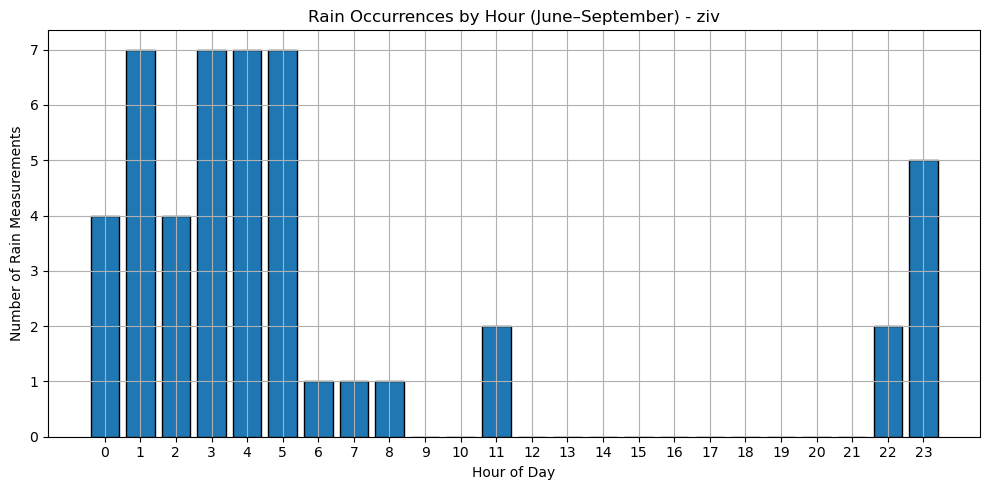

In [6]:
plot_summer_hourly_rain_histogram(ziv_rain_df, station_name='ziv')


## Extract Main Storms

In [7]:
# Assuming 'Date Time' column is in string format 'd/m/y h/m'
ram_rain_df['date_time'] = pd.to_datetime(ram_rain_df['date_time'])

# Extract dates where Rain Intensity is greater than 10
high_intensity_dates = ram_rain_df[ram_rain_df['rain_intens_10min_mm_hr'] > 10]['date_time']

# Create a DataFrame to store results
result_df = pd.DataFrame(columns=['Start Date', 'End Date'])
for date in high_intensity_dates:
    # Convert date back to string format with desired format
    date_str = date.strftime('%d/%m/%Y %H:%M')
    start_date = pd.to_datetime(date_str, format='%d/%m/%Y %H:%M') - pd.Timedelta(days=.5)
    end_date = pd.to_datetime(date_str, format='%d/%m/%Y %H:%M') + pd.Timedelta(days=.5)
    result_df = result_df.append({'Start Date': start_date.strftime('%d/%m/%Y %H:%M'),
                                  'End Date': end_date.strftime('%d/%m/%Y %H:%M')}, ignore_index=True)

# Display the result DataFrame
print(result_df)


          Start Date          End Date
0   15/10/2023 13:00  16/10/2023 13:00
1   01/11/2023 00:20  02/11/2023 00:20
2   01/11/2023 01:50  02/11/2023 01:50
3   19/11/2023 05:00  20/11/2023 05:00
4   19/11/2023 05:50  20/11/2023 05:50
5   19/11/2023 14:20  20/11/2023 14:20
6   19/11/2023 14:40  20/11/2023 14:40
7   19/11/2023 14:50  20/11/2023 14:50
8   19/11/2023 20:30  20/11/2023 20:30
9   23/12/2023 22:10  24/12/2023 22:10
10  25/01/2024 20:00  26/01/2024 20:00
11  25/01/2024 20:10  26/01/2024 20:10
12  26/01/2024 05:10  27/01/2024 05:10
13  26/01/2024 05:20  27/01/2024 05:20
14  26/01/2024 05:30  27/01/2024 05:30
15  26/01/2024 08:00  27/01/2024 08:00
16  26/01/2024 09:20  27/01/2024 09:20
17  26/01/2024 18:30  27/01/2024 18:30
18  26/01/2024 18:40  27/01/2024 18:40
19  26/01/2024 20:30  27/01/2024 20:30
20  26/01/2024 20:40  27/01/2024 20:40
21  27/02/2024 01:10  28/02/2024 01:10
22  18/03/2024 03:00  19/03/2024 03:00
23  18/03/2024 04:30  19/03/2024 04:30
24  18/03/2024 07:20  19/

C:\Users\raznu\AppData\Local\Temp\ipykernel_25916\4171058422.py:14: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  result_df = result_df.append({'Start Date': start_date.strftime('%d/%m/%Y %H:%M'),
C:\Users\raznu\AppData\Local\Temp\ipykernel_25916\4171058422.py:14: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  result_df = result_df.append({'Start Date': start_date.strftime('%d/%m/%Y %H:%M'),
C:\Users\raznu\AppData\Local\Temp\ipykernel_25916\4171058422.py:14: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  result_df = result_df.append({'Start Date': start_date.strftime('%d/%m/%Y %H:%M'),
C:\Users\raznu\AppData\Local\Temp\ipykernel_25916\4171058422.py:14: FutureWarning: The frame.append method is deprecated and will be removed f

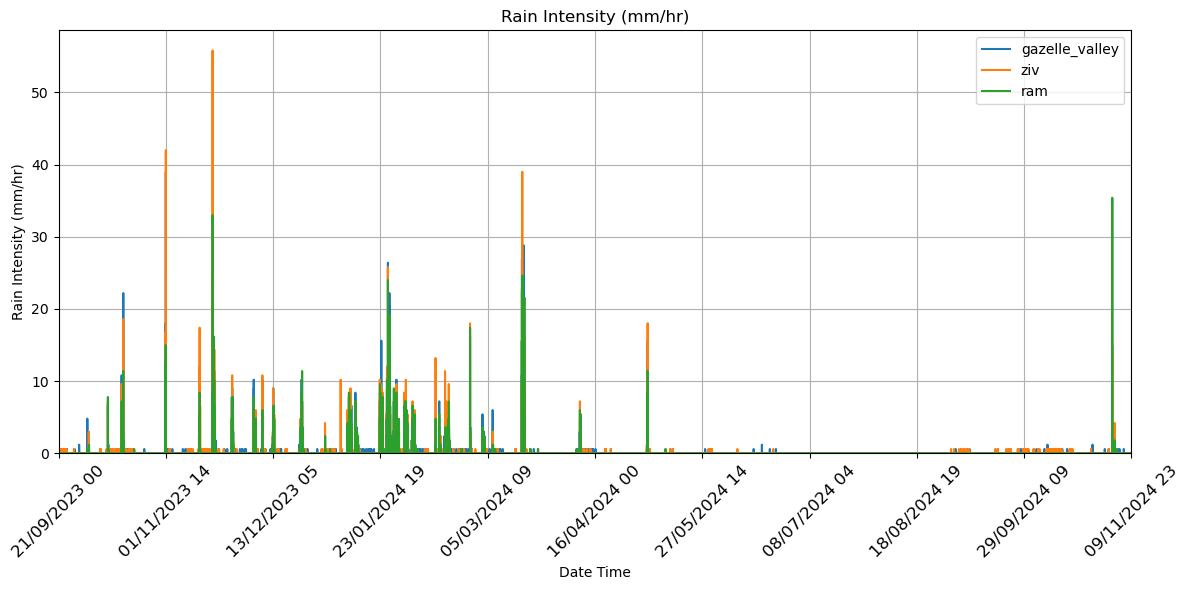

In [8]:
plot_rain_intensity([gv_rain_df, ziv_rain_df, ram_rain_df], '21/09/2023 00:30', '10/11/2024 00:00')

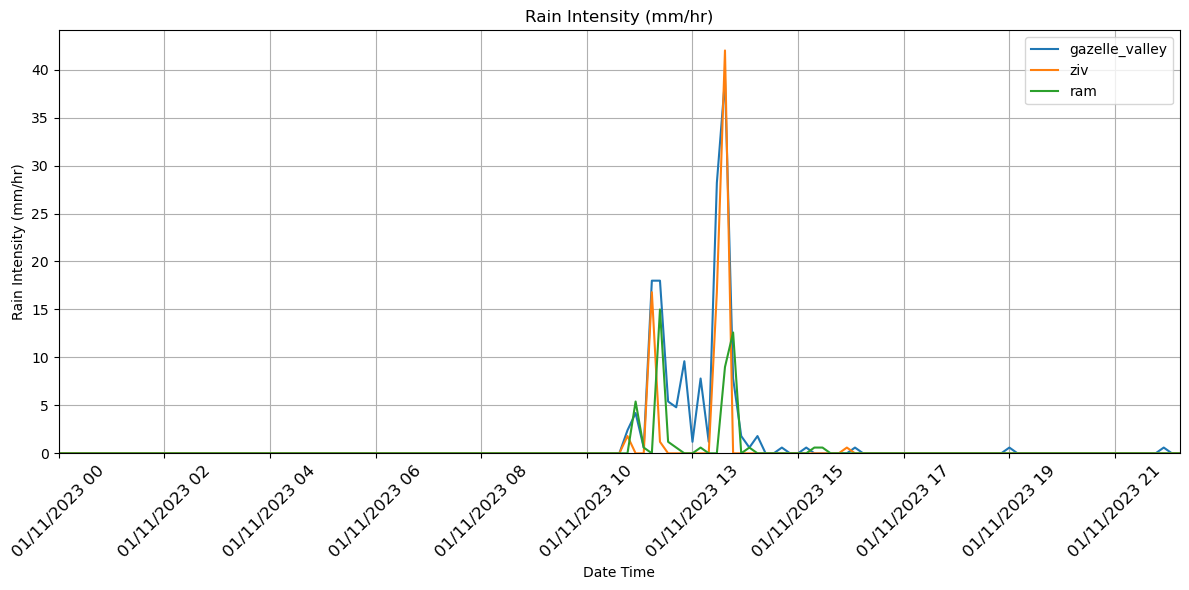

In [9]:
plot_rain_intensity([gv_rain_df, ziv_rain_df, ram_rain_df], '01/11/2023 00:00', '01/11/2023 23:00')

## Cumulative Rain

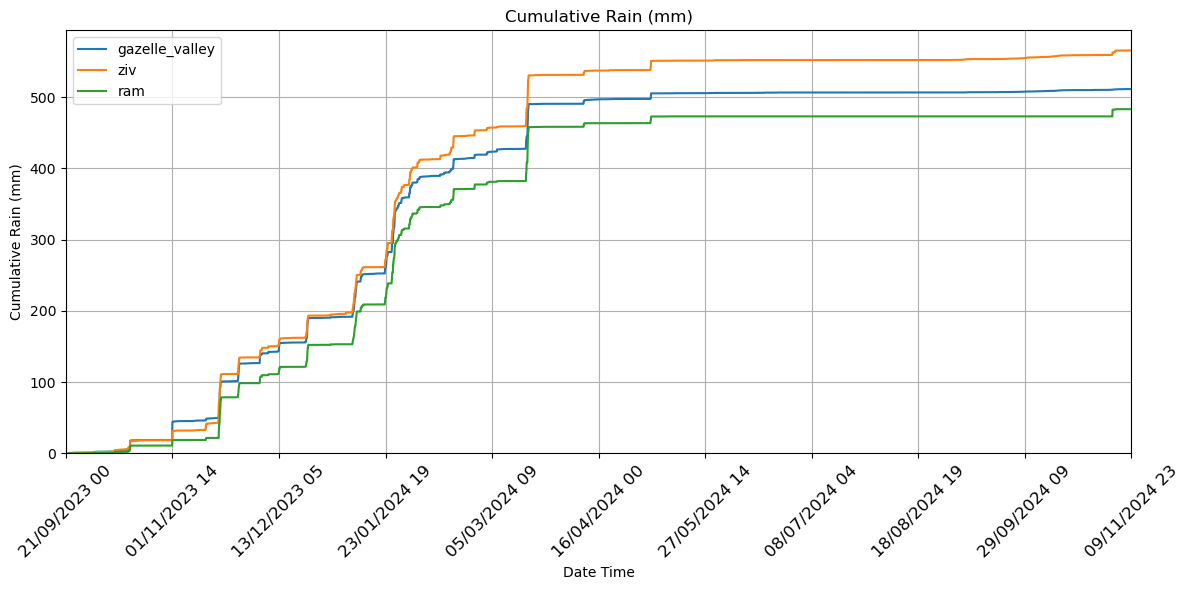

In [10]:
plot_cumulative_rain([gv_rain_df, ziv_rain_df, ram_rain_df], '21/09/2023 00:30', '10/11/2024 00:00')

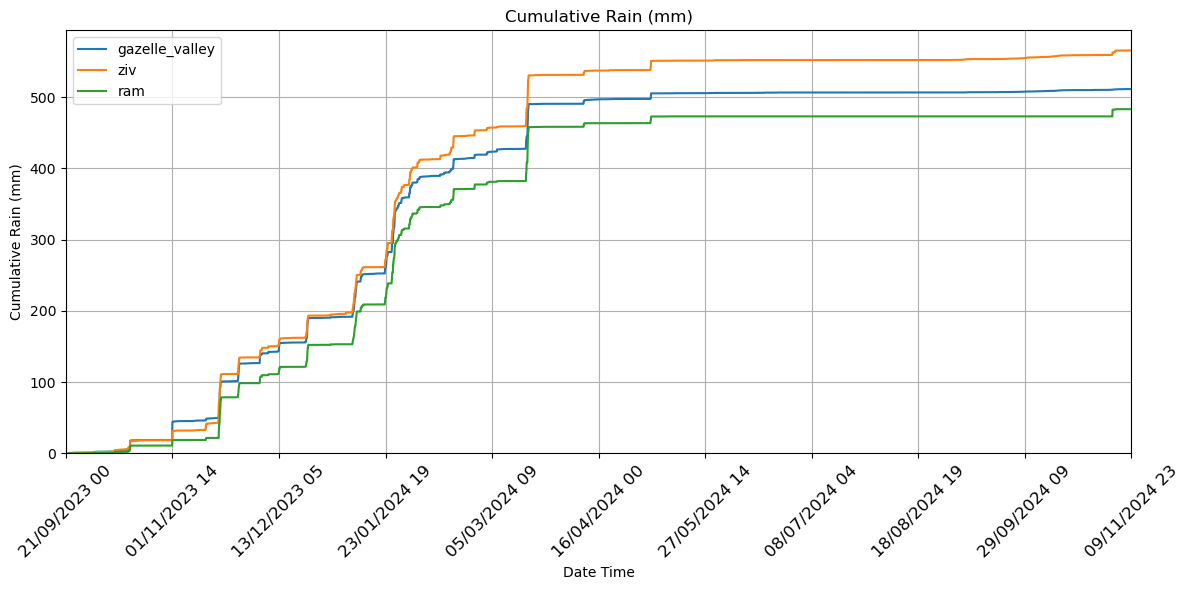

In [11]:
plot_cumulative_rain([gv_rain_df, ziv_rain_df, ram_rain_df], '21/09/2023 00:30', '10/11/2024 00:00')

In [12]:
ram_rain_df

,date_time,rain_mm,rain_intens_10min_mm_hr
0,2023-09-01 00:00:00,0.0,0.0
1,2023-09-01 00:10:00,0.0,0.0
2,2023-09-01 00:20:00,0.0,0.0
3,2023-09-01 00:30:00,0.0,0.0
4,2023-09-01 00:40:00,0.0,0.0
...,...,...,...
84598,2025-04-10 11:40:00,0.0,0.0
84599,2025-04-10 11:50:00,0.0,0.0
84600,2025-04-10 12:00:00,0.0,0.0
84601,2025-04-10 12:10:00,0.0,0.0


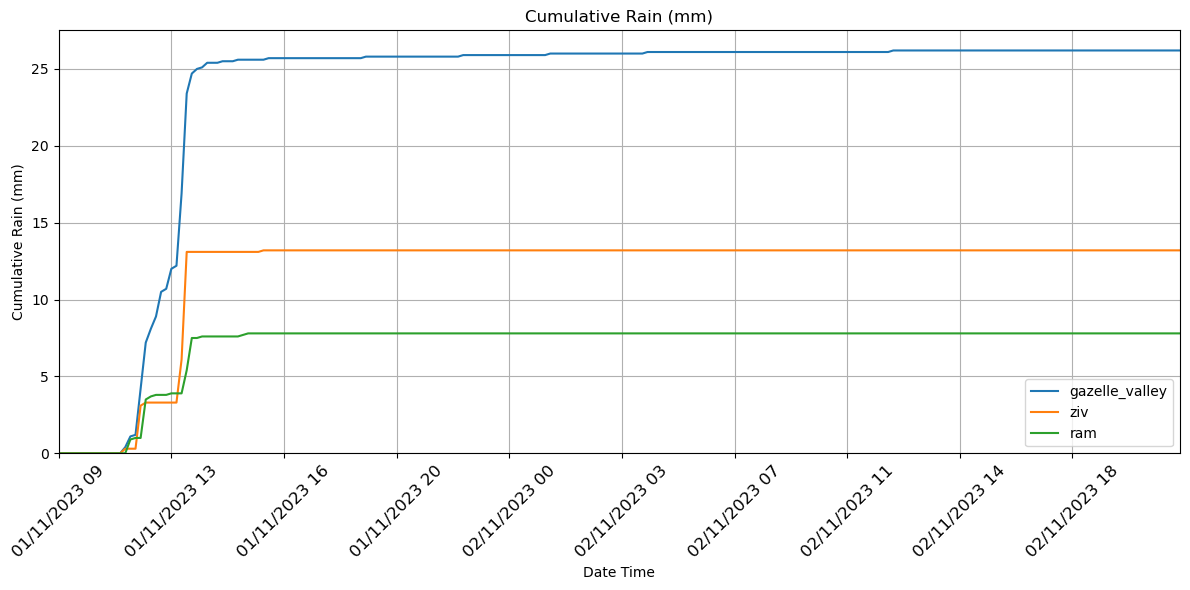

In [13]:
plot_cumulative_rain([gv_rain_df, ziv_rain_df, ram_rain_df], '01/11/2023 09:30', '02/11/2023 22:00')